# Exercise 2: Decision Trees

In this assignment you will implement a Decision Tree algorithm as learned in class.

## Do not start the exercise until you fully understand the submission guidelines.

* The homework assignments are executed automatically. 
* Failure to comply with the following instructions will result in a significant penalty. 
* Appeals regarding your failure to read these instructions will be denied. 
* Kindly reminder: the homework assignments contribute 50% of the final grade.

## Read the following instructions carefully:

1. This Jupyter notebook contains all the step-by-step instructions needed for this exercise.
1. Write **efficient**, **vectorized** code whenever possible. Some calculations in this exercise may take several minutes when implemented efficiently, and might take much longer otherwise. Unnecessary loops will result in point deductions.
1. You are responsible for the correctness of your code and should add as many tests as you see fit to this jupyter notebook. Tests will not be graded nor checked.
1. Complete the required functions in `hw2.py` script only. This exercise is graded automatically, and only the `hw2.py` script is tested.
1. You are allowed to use functions and methods from the [Python Standard Library](https://docs.python.org/3/library/), numpy and pandas only. **Do not import anything else.**
1. Your code must run without errors. Use at least `numpy` 1.15.4. Any code that cannot run will not be graded.
1. Write your own code. Cheating will not be tolerated.
1. Submission includes a zip file that contains the `hw2.py` script as well as this notebook, with your ID as the file name. For example, `hw2_123456789_987654321.zip` if you submitted in pairs and `hw2_123456789.zip` if you submitted the exercise alone. 

Please use only a **zip** file in your submission.

---
---

## Please sign that you have read and understood the instructions: 

### IDs:

ID_1: 342681004


ID_2: 026548446

---
---

# I have read and understood the instructions: *** YOUR ID HERE ***

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# make the notebook automatically reload external python modules
%load_ext autoreload
%autoreload 2

## Warmup - OOP in python

Our desicion tree will be implemented using a dedicated python class. Python classes are very similar to classes in other object oriented programming languages you might be familiar with.


You can use the following [site](https://jeffknupp.com/blog/2014/06/18/improve-your-python-python-classes-and-object-oriented-programming/) to learn about classes in python.

In [2]:
class Node(object):
    def __init__(self, data):
        self.data = data
        self.children = []

    def add_child(self, node):
        self.children.append(node)

In [3]:
n = Node(5)
p = Node(6)
q = Node(7)
n.add_child(p)
n.add_child(q)
n.children

[<__main__.Node at 0x138822cfda0>, <__main__.Node at 0x138822cfe00>]

## Data preprocessing

For the following exercise, we will use a dataset containing mushroom data `agaricus-lepiota.csv`. 

This data set includes descriptions of hypothetical samples corresponding to 23 species of gilled mushrooms in the Agaricus and Lepiota Family. Each species is identified as definitely edible, definitely poisonous, or of unknown edibility and not recommended. This latter class was combined with the poisonous
one (=there are only two classes **edible** and **poisonous**). 
    
The dataset contains 8124 observations with 21 features and the class:
1. cap-shape: bell=b,conical=c,convex=x,flat=f,knobbed=k,sunken=s
1. cap-surface: fibrous=f,grooves=g,scaly=y,smooth=s
1. cap-color: brown=n,buff=b,cinnamon=c,gray=g,green=r,pink=p,purple=u,red=e,white=w,yellow=y
1. bruises: bruises=t,no=f
1. odor: almond=a,anise=l,creosote=c,fishy=y,foul=f, musty=m,none=n,pungent=p,spicy=s
1. gill-attachment: attached=a,descending=d,free=f,notched=n
1. gill-spacing: close=c,crowded=w,distant=d
1. gill-size: broad=b,narrow=n
1. gill-color: black=k,brown=n,buff=b,chocolate=h,gray=g,green=r,orange=o,pink=p,purple=u,red=e,white=w,yellow=y
1. stalk-shape: enlarging=e,tapering=t
1. stalk-surface-above-ring: fibrous=f,scaly=y,silky=k,smooth=s
1. stalk-surface-below-ring: fibrous=f,scaly=y,silky=k,smooth=s
1. stalk-color-above-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y
1. stalk-color-below-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y
1. veil-type: partial=p,universal=u
1. veil-color: brown=n,orange=o,white=w,yellow=y
1. ring-number: none=n,one=o,two=t
1. ring-type: cobwebby=c,evanescent=e,flaring=f,large=l,none=n,pendant=p,sheathing=s,zone=z
1. spore-print-color: black=k,brown=n,buff=b,chocolate=h,green=r,orange=o,purple=u,white=w,yellow=y
1. population: abundant=a,clustered=c,numerous=n,scattered=s,several=v,solitary=y
1. habitat: grasses=g,leaves=l,meadows=m,paths=p,urban=u,waste=w,woods=d

First, we will read and explore the data using pandas and the `.read_csv` method. Pandas is an open source library providing high-performance, easy-to-use data structures and data analysis tools for the Python programming language.

In [4]:
# load dataset
data = pd.read_csv('agaricus-lepiota.csv')
data

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,k,s,n,f,n,a,c,b,y,e,...,o,o,p,o,o,p,b,c,l,e
8120,x,s,n,f,n,a,c,b,y,e,...,o,o,p,n,o,p,b,v,l,e
8121,f,s,n,f,n,a,c,b,n,e,...,o,o,p,o,o,p,b,c,l,e
8122,k,y,n,f,y,f,c,n,b,t,...,w,w,p,w,o,e,w,v,l,p


One of the advantages of the Decision Tree algorithm is that almost no preprocessing is required. However, finding missing values is always required.

In [5]:
data = data.dropna(axis=1)

We will split the dataset to `training` and `validation` sets.

In [6]:
from sklearn.model_selection import train_test_split
# Making sure the last column will hold the labels
X, y = data.drop('class', axis=1), data['class']
X = np.column_stack([X,y])
# split dataset using random_state to get the same split each time
X_train, X_validation = train_test_split(X, random_state=99)

print("Training dataset shape: ", X_train.shape)
print("Validation dataset shape: ", X_validation.shape)

Training dataset shape:  (6093, 22)
Validation dataset shape:  (2031, 22)


## Impurity Measures (10 points)

Impurity is a measure of how often a randomly chosen element from the set would be incorrectly labeled if it was randomly labeled according to the distribution of labels in the subset. Implement the functions `calc_gini` and `calc_entropy` in `hw2.py`. You are encouraged to test your implementation according to the expected behavior of those measures as seen in class. (5 points each)

In [7]:
X

array([['x', 's', 'n', ..., 's', 'u', 'p'],
       ['x', 's', 'y', ..., 'n', 'g', 'e'],
       ['b', 's', 'w', ..., 'n', 'm', 'e'],
       ...,
       ['f', 's', 'n', ..., 'c', 'l', 'e'],
       ['k', 'y', 'n', ..., 'v', 'l', 'p'],
       ['x', 's', 'n', ..., 'c', 'l', 'p']],
      shape=(8124, 22), dtype=object)

In [8]:
from hw2 import calc_gini, calc_entropy

In [9]:
calc_gini(X)

np.float64(0.4995636322379775)

In [10]:
##### Your tests here #####

calc_gini(X), calc_entropy(X)

(np.float64(0.4995636322379775), np.float64(0.9993703627906085))

## Building a Decision Tree 

### Implement the class `DecisionNode` in `hw2.py` (20 points)

Use a Python class to construct the decision tree. Your class should support the following functionality:

1. Initiating a node for a decision tree. You will need to use several class methods and class attributes that appear in `hw2.py`. 
1. Note the following attributes and methods for each node:
    1. `self.data` holds the relevant data to split that node (ndarray).
    1. `self.impurity_func` holds the impurity function to use for the node (func).
    1. `self.feature` holds the best feature that splits the node (int).
    1. `self.pred` holds the prediction of the entire node (string).
    1. `self.depth` holds the depth of the node (int).
    1. `self.children` holds the objects of the children of the node (list).
    1. `self.children_values` holds the value of the feature associated with the children (list).
    1. `self.terminal` determines if the node is a leaf (boolean).
    1. `self.chi` holds the chi square value (int).
    1. `self.max_depth` holds the maximum allowed depth of the entire tree (int).
    1. `self.gain_ratio` determines if gain_ratio is used (boolean).
    1. `self.feature_importance` holds the feature importance of the chosen feature.

1. Your code should support both Gini and Entropy as impurity measures. 
1. The provided data includes categorical data. In this exercise, when splitting a node create the number of children needed according to the attribute unique values.
1. Complete the class `DecisionNode`. Implementation details are up to you, but maintain the function signature and outputs. Make sure you are not changing the provided functions / variables we provided.
1. Read below about goodness of split, to implement the relevant method. Make sure to test it
1. You can create auxiliary functions, methods and variables.

### Goodness of Split (10 Points)

Given some feature, the Goodnees of Split measures the reduction in the impurity if we split the data according to the feature.
$$
\Delta\varphi(S, A) = \varphi(S) - \sum_{v\in Values(A)} \frac{|S_v|}{|S|}\varphi(S_v)
$$

In our implementation the goodness_of_split function will return either the Goodness of Split or the Gain Ratio as learned in class. You'll control the return value with the `gain_ratio` parameter. If this parameter will set to False (the default value) it will return the regular Goodness of Split. If it will set to True it will return the Gain Ratio.
$$
GainRatio(S,A)=\frac{InformationGain(S,A)}{SplitInformation(S,A)}
$$
Where:
$$
InformationGain(S,A)=Goodness\ of\ Split\ calculated\ with\ Entropy\ as\ the\ Impurity\ function \\
SplitInformation(S,A)=- \sum_{a\in A} \frac{|S_a|}{|S|}\log\frac{|S_a|}{|S|}
$$

Implement the method `goodness_of_split` in `DecisionNode` in `hw2.py`.

### Feture Importance (5 points) 

Feature importance (FI) is calculated as the decrease in node impurity weighted by the probability of reaching that node. The node probability can be calculated by the number of samples that reach the node, divided by the total number of samples. The higher the value the more important the feature.

$$
FI = \frac{|S|}{|S_{total}|}\varphi(S) - \sum_{v\in Values(A)} \frac{|S_v|}{|S_{total}|}\varphi(S_v)
$$

Note that:

$$
FI = \frac{|S|}{|S_{total}|}\Delta\varphi(S, A)
$$

Implement the method `calc_feature_importance` in `DecisionNode` in `hw2.py`.

In [11]:
from hw2 import DecisionNode

In [12]:
##### Your tests here #####

# python support passing a function as arguments to another function.
gini_node = DecisionNode(X, calc_gini)
entropy_node = DecisionNode(X, calc_entropy)
goodness_gini, split_values_gini = gini_node.goodness_of_split(0)
goodness_entropy, split_values_entropy = entropy_node.goodness_of_split(0)

goodness_gini, goodness_entropy

(np.float64(0.0199596578344422), np.float64(0.030727291723502415))

### Implement the class `DecisionTree` in `hw2.py` (10 points)

Use a Python class to hold the decision tree. Your class should support the following functionality:
1. Build the tree from the root
1. Predict a given instance (see below)
1. Evaluate the accuracy of the tree (see below)
1. Note the following attributes and methods for each node:
    1. `self.data` holds the relevant data to split that node (ndarray).
    1. `self.impurity_func` holds the impurity function to use for the node (func).
    1. `self.chi` holds the chi square p-value (float).
    1. `self.max_depth` holds the maximum allowed depth of the entire tree (int).
    1. `self.gain_ratio` determines if gain_ratio is used (boolean).
1. Complete the class `DecisionTree`. Implementation details are up to you, but maintain the function signature and outputs. Make sure you are not changing the provided functions / variables we provided.
1. Don't forget to calculate the feature importance. You can calculate the feature importance for each node during the building or after.
1. You can add functions to the class.

In [13]:
from hw2 import DecisionTree

In [14]:
##### Your tests here #####
tree_gini = DecisionTree(data=X_train, impurity_func=calc_gini) # gini and goodness of split
tree_gini.build_tree()

tree_entropy = DecisionTree(data=X_train, impurity_func=calc_entropy) # entropy and goodness of split
tree_entropy.build_tree()

tree_entropy_gain_ratio = DecisionTree(data=X_train, impurity_func=calc_entropy, gain_ratio=True) # entropy and gain ratio
tree_entropy_gain_ratio.build_tree()

## Tree evaluation (10 points) 

Implement the methods `predict` and `calc_accuracy` in `DecisionTree` in `hw2.py`

After building the three trees using the training set, you should calculate the accuracy on the validation set. For each tree print the training and validation accuracy. Select the tree that gave you the best validation accuracy. For the rest of the exercise, use that tree (when you asked to build another tree use the same impurity function and same gain_ratio flag). 

In [15]:
##### Your tests here #####

print('gini', tree_gini.calc_accuracy(X_train), tree_gini.calc_accuracy(X_validation))
print('entropy', tree_entropy.calc_accuracy(X_train), tree_entropy.calc_accuracy(X_validation))
print('entropy gain ratio', tree_entropy_gain_ratio.calc_accuracy(X_train), 
      tree_entropy_gain_ratio.calc_accuracy(X_validation))

gini 99.24503528639423 77.49876907927128
entropy 99.40915805022156 77.25258493353027
entropy gain ratio 99.63892991957984 78.53274249138356


## Depth pruning (5 points)

In this part, we will investigate the effect the max depth of the tree has on the training and validation accuracies.

For each max_depth value in the range [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], construct a tree and prune it according to the max_depth value (don't let the tree to grow beyond this depth). Next, calculate the training and validation accuracy on the resulting trees. 

In order to debug and self-test your code, draw the training and validation accuracy as a function of the max_depth and verify that your results make sense. The red dot denotes the best model according to the validation accuracy.

Implement the function `depth_pruning` in `hw2.py`.

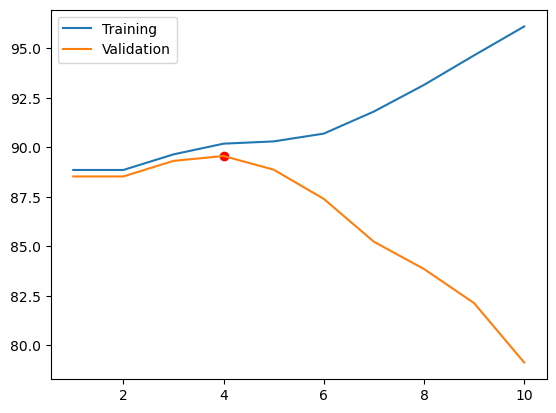

In [16]:
##### Your tests here #####
from hw2 import depth_pruning
depth_training_acc, depth_validation_acc = depth_pruning(X_train, X_validation)

plt.plot(range(1, 11), depth_training_acc, label='Training')
plt.plot(range(1, 11), depth_validation_acc, label='Validation')
plt.scatter(np.argmax(depth_validation_acc)+1, max(depth_validation_acc), c='r')
plt.legend();

## Chi square pre-pruning (10 points)

Consider the following p-value cut-off values: [1 (no pruning), 0.5, 0.25, 0.1, 0.05, 0.0001 (max pruning)]. For each value, construct a tree and prune it according to the cut-off value. Next, calculate the training and validation accuracy on the resulting trees. 

In order to debug and self-test your code, draw the training and validation accuracy as a function of the tuple (p-value, tree depth) and verify that your results make sense. The red dot denotes the best model according to the validation accuracy.

Implement the function `chi_pruning` in `hw2.py`.

In [17]:
from hw2 import chi_pruning

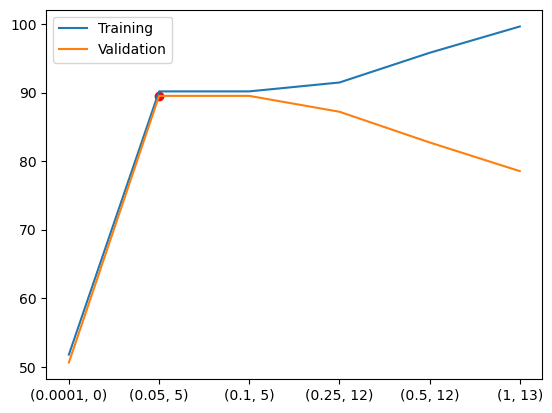

In [18]:
##### Your tests here #####

chi_training_acc, chi_validation_acc, depth = chi_pruning(X_train, X_validation)
chi_values = [1, 0.5, 0.25, 0.1, 0.05, 0.0001]
chi_depth_tuple = [str((x, y)) for x, y in zip(chi_values, depth)][::-1]
plt.plot(chi_depth_tuple, chi_training_acc[::-1], label='Training')
plt.plot(chi_depth_tuple, chi_validation_acc[::-1], label='Validation')
plt.scatter(chi_depth_tuple[np.argmax(chi_validation_acc[::-1])], max(chi_validation_acc), c='r')
plt.legend();

Build the best 2 trees:
1. tree_max_depth - the best tree according to max_depth pruning
1. tree_chi - the best tree according to chi square pruning

In [19]:
max_depth_idx = np.argmax(depth_validation_acc)
max_depth_tree = max_depth_idx + 1

tree_max_depth = DecisionTree(
            data=X_train, 
            impurity_func=calc_entropy, 
            max_depth=max_depth_tree,
            chi=1,
            gain_ratio=True
        )

tree_max_depth.build_tree()

print("Best max_depth:", max_depth_tree)
print("Training accuracy:", tree_max_depth.calc_accuracy(X_train))
print("Validation accuracy:", tree_max_depth.calc_accuracy(X_validation))

max_chi_idx = np.argmax(chi_validation_acc)
best_chi = chi_values[max_chi_idx]
tree_chi = DecisionTree(
            data=X_train, 
            impurity_func=calc_entropy, 
            chi=best_chi,
            max_depth=1000,
            gain_ratio=True
        )
tree_chi.build_tree()

print("Best chi:", best_chi)
print("Training accuracy:", tree_chi.calc_accuracy(X_train))
print("Validation accuracy:", tree_chi.calc_accuracy(X_validation))

Best max_depth: 4
Training accuracy: 90.1854587231249
Validation accuracy: 89.561792220581
Best chi: 0.1
Training accuracy: 90.16904644674216
Validation accuracy: 89.51255539143278


## Number of Nodes (5 points) 

Of the two trees above we will choose the one with fewer nodes.

Complete the function counts_nodes and print the number of nodes in each tree

Implement the function `count_nodes` in `hw2.py`.

In [20]:
from hw2 import count_nodes

In [21]:
##### Your tests here #####
print(count_nodes(tree_max_depth.root))
print(count_nodes(tree_entropy_gain_ratio.root))
print(count_nodes(tree_chi.root))

205
3251
55


## Print the tree

We provided you with a function that should print your tree for your own debugging purposes. 

This code prints:
```
[ROOT, feature=X0, importance=?],
  [X0=a, feature=X2, importance=?]
    [X2=c, leaf]: [{1.0: 10}]
    [X2=d, leaf]: [{0.0: 10}]
  [X0=y, feature=X5, importance=?], 
       [X5=a, leaf]: [{1.0: 5}]
       [X5=s, leaf]: [{0.0: 10}]
  [X0=e, leaf]: [{0.0: 25, 1.0: 50}]
```

In [22]:
def print_tree(node, depth=0, parent_feature='ROOT', feature_val='ROOT'):
    '''
    prints the tree according to the example above

    Input:
    - node: a node in the decision tree

    This function has no return value
    '''
    if node.terminal == False:
        if node.depth == 0:
            print('[ROOT, feature=X{}, importance={:.3f}]'.format(node.feature, node.feature_importance))
        else:
            print('{}[X{}={}, feature=X{}, importance={:.3f}], Depth: {}'.format(depth*'  ', parent_feature, 
                                                                             feature_val, node.feature, 
                                                                             node.feature_importance, node.depth))
        for i, child in enumerate(node.children):
            print_tree(child, depth+1, node.feature, node.children_values[i])
    else:
        classes_count = {}
        labels, counts = np.unique(node.data[:, -1], return_counts=True)
        for l, c in zip(labels, counts):
            classes_count[l] = c
        print('{}[X{}={}, leaf]: [{}], Depth: {}'.format(depth*'  ', parent_feature, feature_val,
                                                         classes_count, node.depth))